In [6]:
# import des modules
import pandas as pd
from collections import Counter
from itertools import chain
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

## 1. Préparation des données

In [ ]:
# jeu de données complet (15 227 publication)
df = pd.read_csv("openalex_vietnam_new_year_to_use.csv")
df

,id,title,publication_year,language,type,institution_countries,institutions,domains,fields,subfields,topics,primary_topic_name,primary_topic_field_name,primary_topic_subfield_name,primary_topic_domain_name,referenced_ids,referenced_count,lang_type,referenced_ids_internal
0,https://openalex.org/W3024878631,The long-run impact of bombing Vietnam,2010,en,article,GB; US,Centre for Economic Policy Research; Universit...,Geography; Political science; Economics; Socio...,Development economics; Economic growth; Socioe...,Vietnam War; Poverty; Population; Instrumental...,Strategic bombing,"Defense, Military, and Policy Studies","Economics, Econometrics and Finance",Economics and Econometrics,Social Sciences,https://openalex.org/W2171656257; https://open...,79,américain,NaN
1,https://openalex.org/W2133466515,Psychophysiologic Assessment of Posttraumatic ...,1987,en,article,US,United States Department of Veterans Affairs,Psychology; Geography,Clinical psychology; Psychiatry; Archaeology,Posttraumatic stress; Vietnam War,NaN,Posttraumatic Stress Disorder Research,Psychology,Clinical Psychology,Social Sciences,https://openalex.org/W1971449933; https://open...,18,américain,NaN
2,https://openalex.org/W3123011427,Interfirm Relationships and Informal Credit in...,1999,en,article,US,"Stanford University; University of California,...",Business; Political science,Finance; Law,Default; Enforcement,NaN,Working Capital and Financial Performance,"Business, Management and Accounting",Accounting,Social Sciences,https://openalex.org/W3123550268; https://open...,32,américain,NaN
3,https://openalex.org/W2041685217,Learning and foreign policy: sweeping a concep...,1994,en,article,US,"Rutgers, The State University of New Jersey",History; Political science; Sociology,Economic history; Political economy; Law; Clas...,Politics; German; Paradise; Mythology; Vietnam...,Foreign policy,International Relations and Foreign Policy,Social Sciences,Political Science and International Relations,Social Sciences,https://openalex.org/W5855877; https://openale...,140,américain,"['https://openalex.org/W2048335617', 'https://..."
4,https://openalex.org/W2049228636,The Pretty Prudent Public: Post Post-Vietnam A...,1992,en,article,US,"University of California, Davis",Political science,Law,Vietnam War; Politics,Public opinion,Military and Defense Studies,Social Sciences,Political Science and International Relations,Social Sciences,https://openalex.org/W183747230; https://opena...,18,américain,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15222,https://openalex.org/W4323244376,Constitution et passé,2023,fr,book,FR,Aix-Marseille Université,Philosophy; Art; Political science,Humanities; Law,Constitution,NaN,European Political History Analysis,Arts and Humanities,History,Social Sciences,https://openalex.org/W1964769226; https://open...,16,français,NaN
15223,https://openalex.org/W2753079631,"""I Am Contemporary!"": The Life and Times of Pe...",1996,en,dissertation,US,Louisiana State University Agricultural Center,Art; History; Sociology; Geography,Art history; Visual arts; Media studies; Carto...,Performance art; Heaven,NaN,Music History and Culture,Arts and Humanities,Music,Social Sciences,https://openalex.org/W6828547186; https://open...,35,américain,NaN
15224,https://openalex.org/W2806220170,Senior citizens as an emerging force in Americ...,1990,en,article,US,The Ohio State University,Political science; Sociology,Public relations; Political economy; Law,Politics,NaN,Social Policy and Reform Studies,Social Sciences,Political Science and International Relations,Social Sciences,NaN,0,américain,NaN
15225,https://openalex.org/W4312622443,Secouer le lecteur. Perspective narrative et f...,2022,fr,book-chapter,BR; GB; PL; US,Adam Mickiewicz University in Poznań; Centro U...,Art; History,Literature; Visual arts,Narrative; Perspective (graphical),NaN,Narrative Theory and Analysis,Arts and Humanities,Literature and Literary Theory,Social Sciences,https:/

In [ ]:
# création d'un sous jeu de données pour chaque pays
france = df[df["lang_type"] == "français"].reset_index(drop=True)
etats_unis = df[df["lang_type"] == "américain"].reset_index(drop=True)
vietnam = df[df["lang_type"] == "vietnamien"].reset_index(drop=True)
france_etats_unis = df[df["lang_type"] == "franco_américain"].reset_index(drop=True)

In [8]:
# comptage des sous-domaines avec counter et itertools car valeurs multiples avec séparateurs
subfields = Counter(chain.from_iterable(v.split('; ') for v in df["subfields"].dropna()))
# sous-domaines par pays
sub1 = Counter(chain.from_iterable(v.split('; ') for v in france["subfields"].dropna()))
sub2 = Counter(chain.from_iterable(v.split('; ') for v in etats_unis["subfields"].dropna()))

## 2. Tests de proportion

### 2.1 Test de l'hypothèse faible : les publications américaines sur le vietnam sont plus focalisées sur la guerre du Vietnam que les populations françaises (sous-domaine : Vietnam War)

In [10]:
x_us = sub2["Vietnam War"]
x_fr = sub1["Vietnam War"]

n_us = len(etats_unis["subfields"])
n_fr = len(france["subfields"])

count = [x_us, x_fr]
nobs = [n_us, n_fr]

z_stat, p_value = proportions_ztest(count,nobs,alternative='larger' ) 

print("z =", z_stat)
print("p-value =", p_value)

z = 5.925141385865242
p-value = 1.5601440472125759e-09


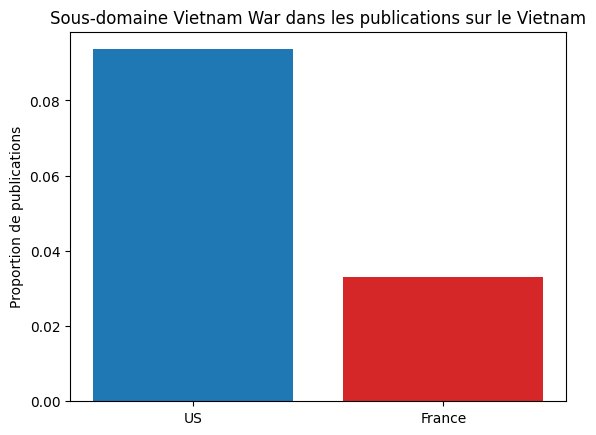

In [13]:

labels = ['US', 'France']
proportions = [x_us/n_us, x_fr/n_fr]

plt.bar(labels, proportions, color = ["tab:blue", "tab:red"])
plt.ylabel("Proportion de publications")
plt.title("Sous-domaine Vietnam War dans les publications sur le Vietnam")
plt.show()

### 2.2 Test de l'hypothèse forte  : les publications américaines sur le Vietnam s'intéressent plus à l'expérience traumatique de la guerre du Vietnam que les publications françaises (topic principal)

In [5]:
# nombre de publications avec topic principal Posttraumatic Stress Disorder Research
x_us = len(etats_unis[etats_unis["primary_topic_name"] == "Posttraumatic Stress Disorder Research"])
x_fr = len(france[france["primary_topic_name"] == "Posttraumatic Stress Disorder Research"])

# nombre total de publications
n_us = len(etats_unis["primary_topic_name"])
n_fr = len(france["primary_topic_name"])

count = [x_us, x_fr]
nobs = [n_us, n_fr]

# test de proportion
z_stat, p_value = proportions_ztest(count,nobs,alternative='larger' ) # p_US > p_FR

print("z =", z_stat)
print("p =", p_value)

z = 3.8550447031484354
p = 5.785424202199501e-05


In [ ]:
#plot
labels = ['US', 'France']
proportions = [x_us/n_us, x_fr/n_fr]

plt.bar(labels, proportions,color = ["tab:blue", "tab:red"])
plt.ylabel("Proportion de publications")
plt.title("Topic PTSD dans les publications sur le Vietnam")
plt.show()